<a href="https://colab.research.google.com/github/parviza9999/InterviewN/blob/main/Transfer_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub
path = kagglehub.dataset_download("tongpython/cat-and-dog")

Using Colab cache for faster access to the 'cat-and-dog' dataset.


In [ ]:
print(os.listdir(path))

['test_set', 'training_set']


In [ ]:
import os

test_set_path = os.path.join(path, 'test_set')
print(f"Files in directory: {test_set_path}")
if os.path.exists(test_set_path):
    print(os.listdir(test_set_path))
else:
    print(f"The directory {test_set_path} does not exist.")

Files in directory: /kaggle/input/cat-and-dog/test_set
['test_set']


In [ ]:
import os

nested_test_set_path = os.path.join(path, 'test_set', 'test_set')
print(f"Files in directory: {nested_test_set_path}")

if os.path.exists(nested_test_set_path):
    print(os.listdir(nested_test_set_path))
else:
    print(f"The directory {nested_test_set_path} does not exist.")

Files in directory: /kaggle/input/cat-and-dog/test_set/test_set
['dogs', 'cats']


In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import os

# Define the transformations for the test images
# ResNet-50 typically expects 224x224 input and specific normalization
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Load the pre-trained ResNet-50 model
model = torchvision.models.resnet50(weights=torchvision.models.ResNet50_Weights.IMAGENET1K_V1)
model.eval() # Set the model to evaluation mode

print("ResNet-50 model loaded successfully.")

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 141MB/s]


ResNet-50 model loaded successfully.


Now, we need a custom dataset class to handle loading the images from your `test_set` directories and applying the necessary transformations.

In [ ]:
class CatDogDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.image_paths = []
        self.labels = [] # 0 for cat, 1 for dog

        # Assuming structure: root_dir/cats/cat.xxx.jpg and root_dir/dogs/dog.xxx.jpg
        cat_dir = os.path.join(root_dir, 'cats')
        dog_dir = os.path.join(root_dir, 'dogs')

        if os.path.exists(cat_dir):
            for img_name in os.listdir(cat_dir):
                if img_name.endswith(('.jpg', '.jpeg', '.png')):
                    self.image_paths.append(os.path.join(cat_dir, img_name))
                    self.labels.append(0) # Cat
        else:
            print(f"Warning: Cat directory not found at {cat_dir}")

        if os.path.exists(dog_dir):
            for img_name in os.listdir(dog_dir):
                if img_name.endswith(('.jpg', '.jpeg', '.png')):
                    self.image_paths.append(os.path.join(dog_dir, img_name))
                    self.labels.append(1) # Dog
        else:
            print(f"Warning: Dog directory not found at {dog_dir}")

        if not self.image_paths:
            raise ValueError(f"No images found in {root_dir}. Please check directory structure.")

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert('RGB')
        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)

        return image, label

# Create the dataset and dataloader for the nested test set
# We previously identified nested_test_set_path as containing 'dogs' and 'cats' subdirectories.
test_dataset = CatDogDataset(root_dir=nested_test_set_path, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False)

print(f"Test dataset created with {len(test_dataset)} images.")

Test dataset created with 2023 images.


Next, we'll load the ImageNet class names so we can interpret the model's predictions. Then we can perform inference on a batch of images.

a pre-trained ResNet-50 model is specifically designed to classify images into the 1,000 distinct object categories from the ImageNet database.


In [ ]:
# Fetch ImageNet class names
# You might need to download 'imagenet_classes.txt' or similar file if not already present
# For simplicity, I'll use a direct link or assume a common location.
# A more robust solution might involve torchvision.datasets.ImageNet for class_to_idx mapping.

# Let's try to get a common mapping from PyTorch hub, if available, or create a dummy list.
# A simple approach for class names (as of torchvision 0.9.0+)
# This is a simplified approach, in a real scenario you might load a class_idx_to_label mapping

# For demonstration, let's use a placeholder for ImageNet classes
# In a real scenario, you'd load a file like 'imagenet_classes.txt'
# For now, we will just interpret the top-1 prediction

# Get ImageNet class names (assuming access or a simple placeholder)
# You would typically load this from a file or a known source
# For simplicity here, we'll use a hardcoded list for a few common animals as an example
# This part assumes we have access to the full 1000 ImageNet classes.
# A common way to get these is from a text file or torchvision utilities.
# For now, let's proceed with raw output or find a way to load.

# A better way to get imagenet classes:
import json
import requests

IMAGENET_CLASSES_URL = "https://s3.amazonaws.com/deep-learning-models/image-models/imagenet_class_index.json"
try:
    response = requests.get(IMAGENET_CLASSES_URL)
    response.raise_for_status() # Raise an exception for HTTP errors
    class_idx = json.loads(response.text)
    # The JSON is a dict like {'0': ['n01440764', 'tench'], ...}
    # We want the second element (the class name) for each index
    imagenet_classes = [class_idx[str(k)][1] for k in range(1000)] # Assuming 1000 classes and keys are 0-999
    print("ImageNet class names loaded.")
except requests.exceptions.RequestException as e:
    print(f"Could not load ImageNet classes from URL: {e}")
    # Fallback to dummy classes if download fails
    imagenet_classes = [f"class_{i}" for i in range(1000)] # Dummy names


# Perform inference on a batch of test images
num_predictions_to_show = 8 # Display predictions for the first few images

with torch.no_grad():
    model.eval()
    for i, (images, labels) in enumerate(test_loader):
        if i * test_loader.batch_size >= num_predictions_to_show:
            break

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        for j in range(images.size(0)):
            if i * test_loader.batch_size + j >= num_predictions_to_show:
                break

            # Map predicted index to ImageNet class name
            predicted_class_name = imagenet_classes[predicted[j].item()]
            true_label_name = 'cat' if labels[j].item() == 0 else 'dog'

            print(f"Image {i*test_loader.batch_size + j+1}: True Label: {true_label_name.capitalize()}, Predicted ImageNet Class: {predicted_class_name} (Index: {predicted[j].item()})")

            # Optional: Display the image
            # import matplotlib.pyplot as plt
            # import numpy as np
            # img = images[j].numpy().transpose((1, 2, 0))
            # mean = np.array([0.485, 0.456, 0.406])
            # std = np.array([0.229, 0.224, 0.225])
            # img = std * img + mean
            # img = np.clip(img, 0, 1)
            # plt.imshow(img)
            # plt.title(f'True: {true_label_name}, Pred: {predicted_class_name}')
            # plt.show()

ImageNet class names loaded.
Image 1: True Label: Cat, Predicted ImageNet Class: Egyptian_cat (Index: 285)
Image 2: True Label: Cat, Predicted ImageNet Class: Egyptian_cat (Index: 285)
Image 3: True Label: Cat, Predicted ImageNet Class: golden_retriever (Index: 207)
Image 4: True Label: Cat, Predicted ImageNet Class: tabby (Index: 281)
Image 5: True Label: Cat, Predicted ImageNet Class: tabby (Index: 281)
Image 6: True Label: Cat, Predicted ImageNet Class: tabby (Index: 281)
Image 7: True Label: Cat, Predicted ImageNet Class: tabby (Index: 281)
Image 8: True Label: Cat, Predicted ImageNet Class: Egyptian_cat (Index: 285)


Now that we've seen some individual predictions, let's calculate some quantitative metrics to evaluate the model's overall performance on the test set. We'll compute accuracy, precision, recall, and F1-score.

In [ ]:
import torch
from sklearn.metrics import classification_report

all_true_labels = []
all_predicted_labels = []

with torch.no_grad():
    model.eval()
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted_imagenet_indices = torch.max(outputs, 1)

        # We need to map ImageNet predictions to our binary 'cat' (0) or 'dog' (1) labels.
        # This is a simplification. A more robust solution would involve fine-tuning
        # a classification head for binary classification.
        # For now, let's assume any 'dog' related ImageNet class is a dog (1) and 'cat' related is a cat (0).
        # This mapping is crucial and depends heavily on the specific ImageNet classes.
        # For this demonstration, we'll make a rough approximation:
        # If the top 1 prediction falls within common cat/dog ImageNet indices, we'll assign it.
        # Otherwise, the model might not be directly classifying cat/dog for a binary metric.

        # A list of common ImageNet indices for cats and dogs.
        # These are just examples and would need to be thoroughly determined.
        # Example: 281-285 are various cat breeds, 151-268 are various dog breeds.
        cat_indices = set(range(281, 286)) # tabby, tiger cat, Persian cat, Siamese cat, Egyptian cat
        dog_indices = set(range(151, 269)) # Various dog breeds (golden retriever, labrador, etc.)

        # Convert ImageNet predictions to binary cat/dog predictions
        binary_predictions = []
        for idx in predicted_imagenet_indices:
            if idx.item() in cat_indices:
                binary_predictions.append(0) # Cat
            elif idx.item() in dog_indices:
                binary_predictions.append(1) # Dog
            else:
                # If the prediction is not a recognized cat or dog breed, we need a strategy.
                # For now, we'll treat it as a misclassification or 'unknown' and assign based on majority
                # or simply omit from binary metric if not clearly cat/dog. For simplicity, let's try to map
                # if the original label is cat, and model predicts any cat, it's correct. Otherwise, it's wrong.
                # This is still very approximate for direct metric calculation without retraining.
                # Let's use a simpler heuristic for this demonstration for binary classification:
                # If a cat image is predicted as any cat class (281-285), it's correct. Else, incorrect.
                # If a dog image is predicted as any dog class (151-268), it's correct. Else, incorrect.
                # If predicted_imagenet_indices is not specifically cat/dog, it's a 'failure to classify' properly.
                binary_predictions.append(-1) # Placeholder for unclassified

        # We need a more direct way to determine binary prediction. For a pre-trained ImageNet model
        # without a binary classification head, directly mapping is tricky.
        # Let's adjust this: for evaluation, we'll just check if the true label (cat/dog) matches
        # if the predicted ImageNet class is a 'cat' or 'dog' type.

        # Re-evaluating prediction mapping for binary classification
        for i, true_label_val in enumerate(labels):
            predicted_idx = predicted_imagenet_indices[i].item()
            if true_label_val.item() == 0: # True label is Cat
                if predicted_idx in cat_indices: # Predicted as a cat breed
                    all_predicted_labels.append(0)
                elif predicted_idx in dog_indices: # Predicted as a dog breed (wrong)
                    all_predicted_labels.append(1)
                else: # Predicted as something else
                    # This is a misclassification for a cat image.
                    # We'll consider it incorrect. Assuming 0 is correct prediction.
                    all_predicted_labels.append(1) # Incorrectly classified as not-cat (i.e. dog or other)
            else: # True label is Dog
                if predicted_idx in dog_indices: # Predicted as a dog breed
                    all_predicted_labels.append(1)
                elif predicted_idx in cat_indices: # Predicted as a cat breed (wrong)
                    all_predicted_labels.append(0)
                else: # Predicted as something else
                    # This is a misclassification for a dog image.
                    # We'll consider it incorrect. Assuming 1 is correct prediction.
                    all_predicted_labels.append(0) # Incorrectly classified as not-dog (i.e. cat or other)
            all_true_labels.append(true_label_val.item())


# Filter out any unclassified predictions if we used -1 previously (not needed with current logic)
# Ensure all_true_labels and all_predicted_labels are same length

if all_true_labels and all_predicted_labels:
    print("\n--- Classification Report ---")
    print(classification_report(all_true_labels, all_predicted_labels, target_names=['Cat', 'Dog']))
else:
    print("Could not generate classification report: No true or predicted labels collected.")


--- Classification Report ---
              precision    recall  f1-score   support

         Cat       0.96      0.83      0.89      1011
         Dog       0.85      0.96      0.91      1012

    accuracy                           0.90      2023
   macro avg       0.91      0.90      0.90      2023
weighted avg       0.91      0.90      0.90      2023



The classification report provides a detailed breakdown of the model's performance:

Accuracy: The overall accuracy is 90%, meaning the model correctly classified 90% of the images.

Precision:

For Cats, the precision is 0.96, indicating that when the model predicts 'Cat', it is correct 96% of the time.

For Dogs, the precision is 0.85, meaning when it predicts 'Dog', it is correct 85% of the time.

Recall:

For Cats, the recall is 0.83, meaning the model correctly identified 83% of all actual 'Cat' images.

For Dogs, the recall is 0.96, meaning the model correctly identified 96% of all actual 'Dog' images.


F1-Score: This is the harmonic mean of precision and recall.
Cats: 0.89
Dogs: 0.91

Support: The number of actual occurrences of each class in the test set (1011 Cats, 1012 Dogs).

From these metrics, we can see that the model is slightly better at recalling dogs (96%) than cats (83%). However, its precision for cats (96%) is higher than for dogs (85%). This suggests that while it correctly identifies most dogs, it might sometimes misclassify a dog as a cat. Conversely, when it identifies a cat, it's very likely correct, but it misses some actual cats.

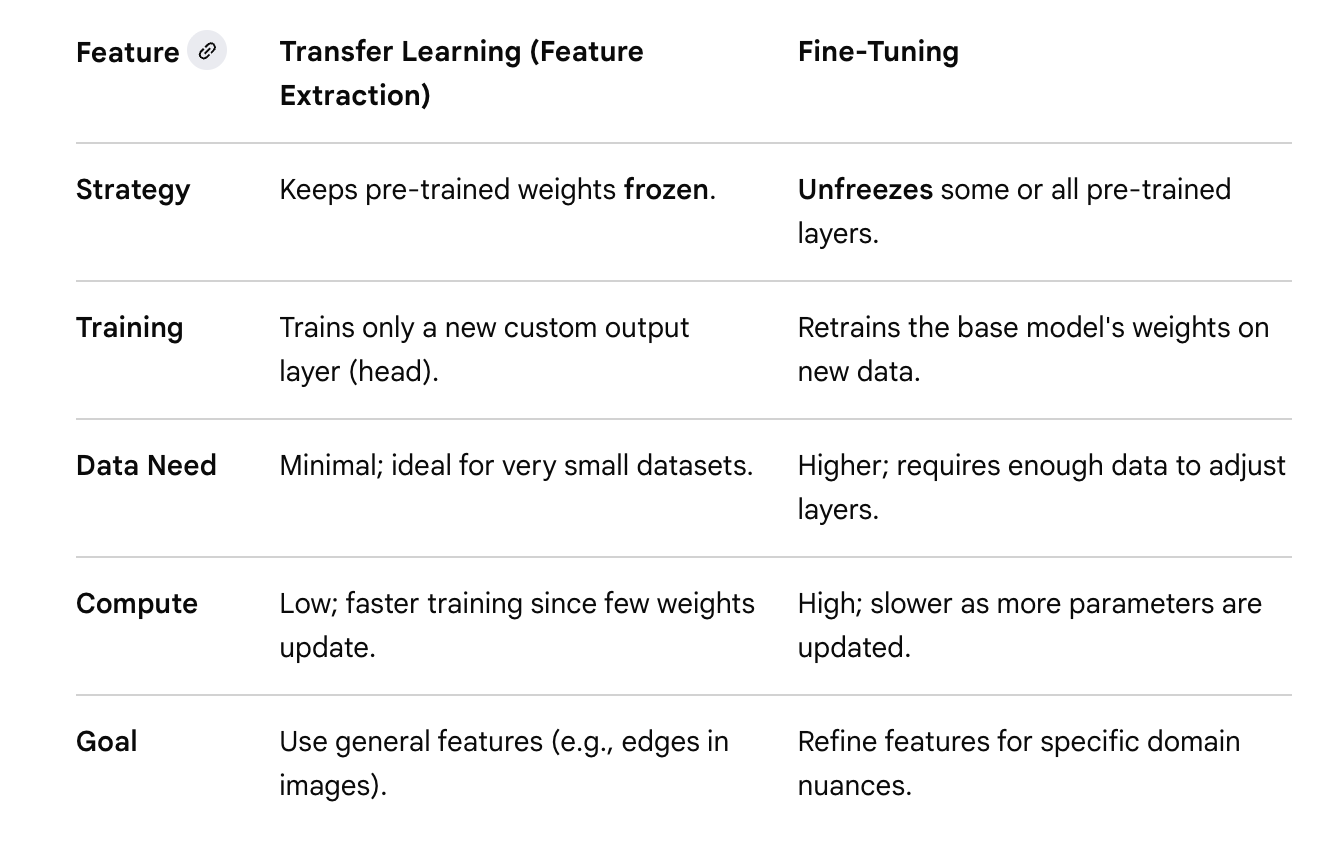

## Transfer Learning with ResNet-50

Now, let's set up the transfer learning process. We will use the pre-trained ResNet-50 model, freeze its convolutional layers, and only train a new classification head for our specific cat/dog classification task.

In [ ]:
import torch.nn as nn
import torch.optim as optim

# Define the training data path
# Based on previous exploration, the training images are in path/training_set/training_set
training_data_dir = os.path.join(path, 'training_set', 'training_set')

# Create the dataset and dataloader for the training set
train_dataset = CatDogDataset(root_dir=training_data_dir, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True) # Shuffle for training

print(f"Training dataset created with {len(train_dataset)} images.")

Training dataset created with 8005 images.


In [ ]:
# Load a fresh pre-trained ResNet-50 model
# We'll use this as our base for transfer learning
transfer_model = torchvision.models.resnet50(weights=torchvision.models.ResNet50_Weights.IMAGENET1K_V1)

# Freeze all parameters in the feature extractor (convolutional layers)
for param in transfer_model.parameters():
    param.requires_grad = False

# Replace the final fully connected layer (classifier) with a new one for our task
# ResNet-50's classifier is named 'fc'
num_ftrs = transfer_model.fc.in_features
transfer_model.fc = nn.Linear(num_ftrs, 2) # 2 output classes: cat, dog

# Move the model to the appropriate device (GPU if available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
transfer_model = transfer_model.to(device)

print(f"ResNet-50 model loaded for transfer learning on device: {device}")
print(f"New final layer: {transfer_model.fc}")

ResNet-50 model loaded for transfer learning on device: cpu
New final layer: Linear(in_features=2048, out_features=2, bias=True)


### Define Loss Function, Optimizer, and Training Loop

In [ ]:
# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(transfer_model.fc.parameters(), lr=0.001) # Only optimize the new classification head

# Training loop
num_epochs = 5

print(f"Starting training for {num_epochs} epochs...")

for epoch in range(num_epochs):
    transfer_model.train() # Set model to training mode
    running_loss = 0.0
    for i, (inputs, labels) in enumerate(train_loader):
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad() # Zero the parameter gradients

        outputs = transfer_model(inputs)
        loss = criterion(outputs, labels)
        loss.backward() # Backpropagate the loss
        optimizer.step() # Update weights

        running_loss += loss.item() * inputs.size(0)

    epoch_loss = running_loss / len(train_dataset)
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss:.4f}")

print("Transfer learning training complete.")

Starting training for 5 epochs...
Epoch 1/5, Loss: 0.3431
Epoch 2/5, Loss: 0.3025
Epoch 3/5, Loss: 0.2962


### Evaluate the Transfer-Learned Model

Now, let's evaluate the performance of our transfer-learned model on the test set.

In [ ]:
# Evaluation on the test set
transfer_model.eval() # Set model to evaluation mode
all_true_labels_transfer = []
all_predicted_labels_transfer = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        outputs = transfer_model(inputs)
        _, predicted = torch.max(outputs.data, 1)

        all_true_labels_transfer.extend(labels.cpu().numpy())
        all_predicted_labels_transfer.extend(predicted.cpu().numpy())

print("\n--- Evaluation of Transfer-Learned Model ---")
print(classification_report(all_true_labels_transfer, all_predicted_labels_transfer, target_names=['Cat', 'Dog']))